## **Langkah Kerja Praktik**

### Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu

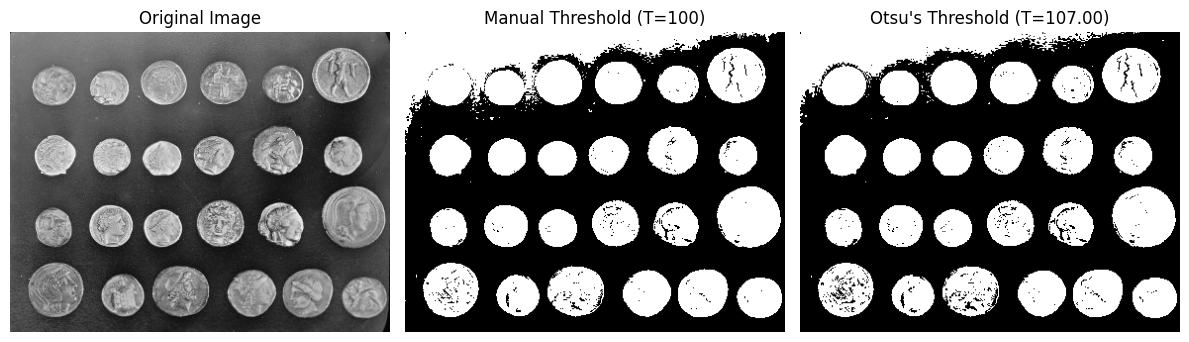

Nilai threshold Otsu yang ditemukan: 107


In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.color import rgb2gray

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()  # Citra sudah grayscale

# 2. Thresholding Global (manual)
# Tentukan nilai ambang manual, misal 100
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\'s Threshold (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

### Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)

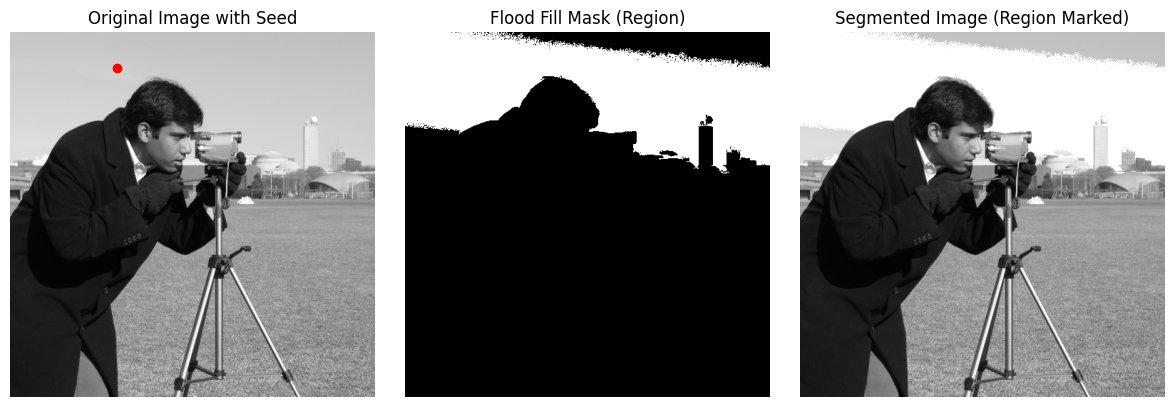

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (benih)
# Misal, kita pilih titik di area langit (misal, koordinat y=50, x=150)
seed_point = (50, 150)

# 3. Terapkan algoritma flood fill (mirip region growing)
# 'tolerance' menentukan seberapa besar perbedaan intensitas yang diizinkan
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra tersegmentasi (tandai region yang 'tumbuh')
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # Tandai region dengan warna putih

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro')  # Tandai seed point
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### Mengubah Titik seed

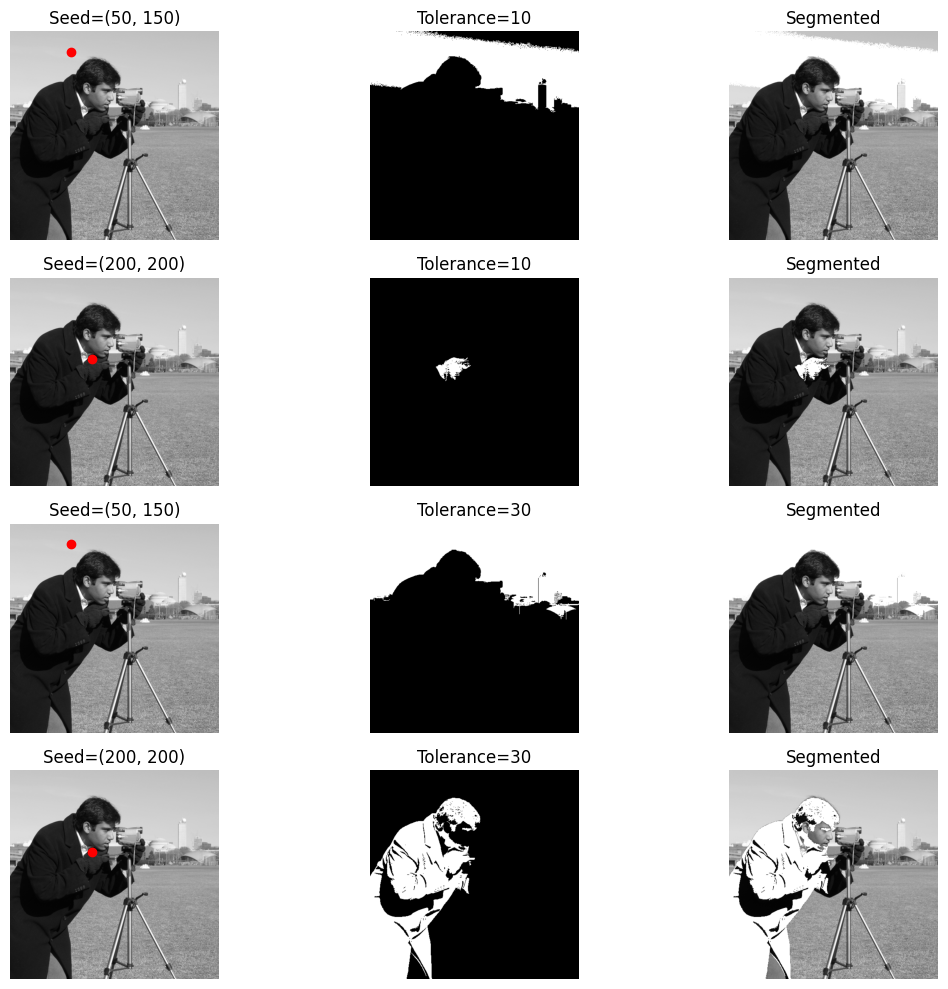

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation

# 1. Memuat citra
image_camera = data.camera()

# 2. Beberapa variasi seed & tolerance
experiments = [
    {"seed": (50, 150), "tolerance": 10},   # langit (awal)
    {"seed": (200, 200), "tolerance": 10},  # area tengah (objek)
    {"seed": (50, 150), "tolerance": 30},   # langit, tolerance besar
    {"seed": (200, 200), "tolerance": 30},  # objek, tolerance besar
]

# 3. Visualisasi
fig, axes = plt.subplots(len(experiments), 3, figsize=(12, 10))

for i, exp in enumerate(experiments):
    seed_point = exp["seed"]
    tolerance = exp["tolerance"]

    flood_mask = segmentation.flood(image_camera, seed_point, tolerance=tolerance)

    segmented_image = np.copy(image_camera)
    segmented_image[flood_mask] = 255

    # Original
    axes[i, 0].imshow(image_camera, cmap='gray')
    axes[i, 0].plot(seed_point[1], seed_point[0], 'ro')
    axes[i, 0].set_title(f'Seed={seed_point}')
    axes[i, 0].axis('off')

    # Mask
    axes[i, 1].imshow(flood_mask, cmap='gray')
    axes[i, 1].set_title(f'Tolerance={tolerance}')
    axes[i, 1].axis('off')

    # Result
    axes[i, 2].imshow(segmented_image, cmap='gray')
    axes[i, 2].set_title('Segmented')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

### Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering

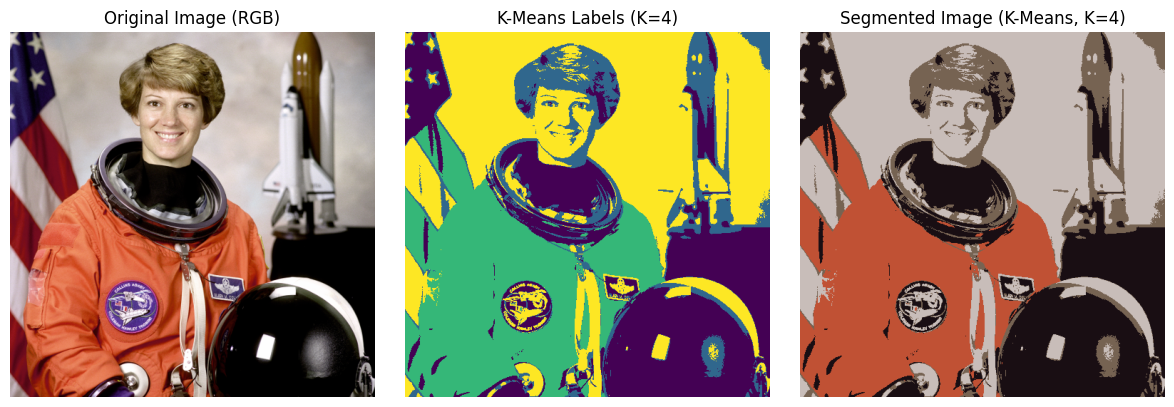

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Memuat citra berwarna (contoh: astronaut)
image_astro = data.astronaut()

# Konversi ke float untuk perhitungan
image_astro_float = image_astro.astype(float) / 255.0

# 2. Reshape citra menjadi array piksel [jumlah_piksel, jumlah_fitur]
# Fitur bisa RGB atau Lab. Ruang warna Lab seringkali lebih baik untuk persepsi warna.
# Konversi ke Lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Terapkan K-Means Clustering
# Tentukan jumlah klaster (segmen) yang diinginkan, misal K=4
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10) # n_init='auto' jika versi sklearn baru

# Hiding FutureWarnings related to default value of n_init
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Reshape label kembali ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Buat citra tersegmentasi (warnai setiap segmen dengan warna rata-rata klaster)
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):
    # Dapatkan piksel yang termasuk klaster k
    cluster_pixels = (pixel_labels == k)
    # Isi piksel tersebut di citra baru dengan warna pusat klaster k
    # Perlu reshape kembali cluster_pixels ke bentuk citra
    mask_k = cluster_pixels.reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB untuk ditampilkan
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# Menampilkan label klaster
ax[1].imshow(segmented_labels, cmap='viridis') # cmap bisa diganti
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

# Menampilkan citra hasil segmentasi K-Means
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### Mengubah Nilai K

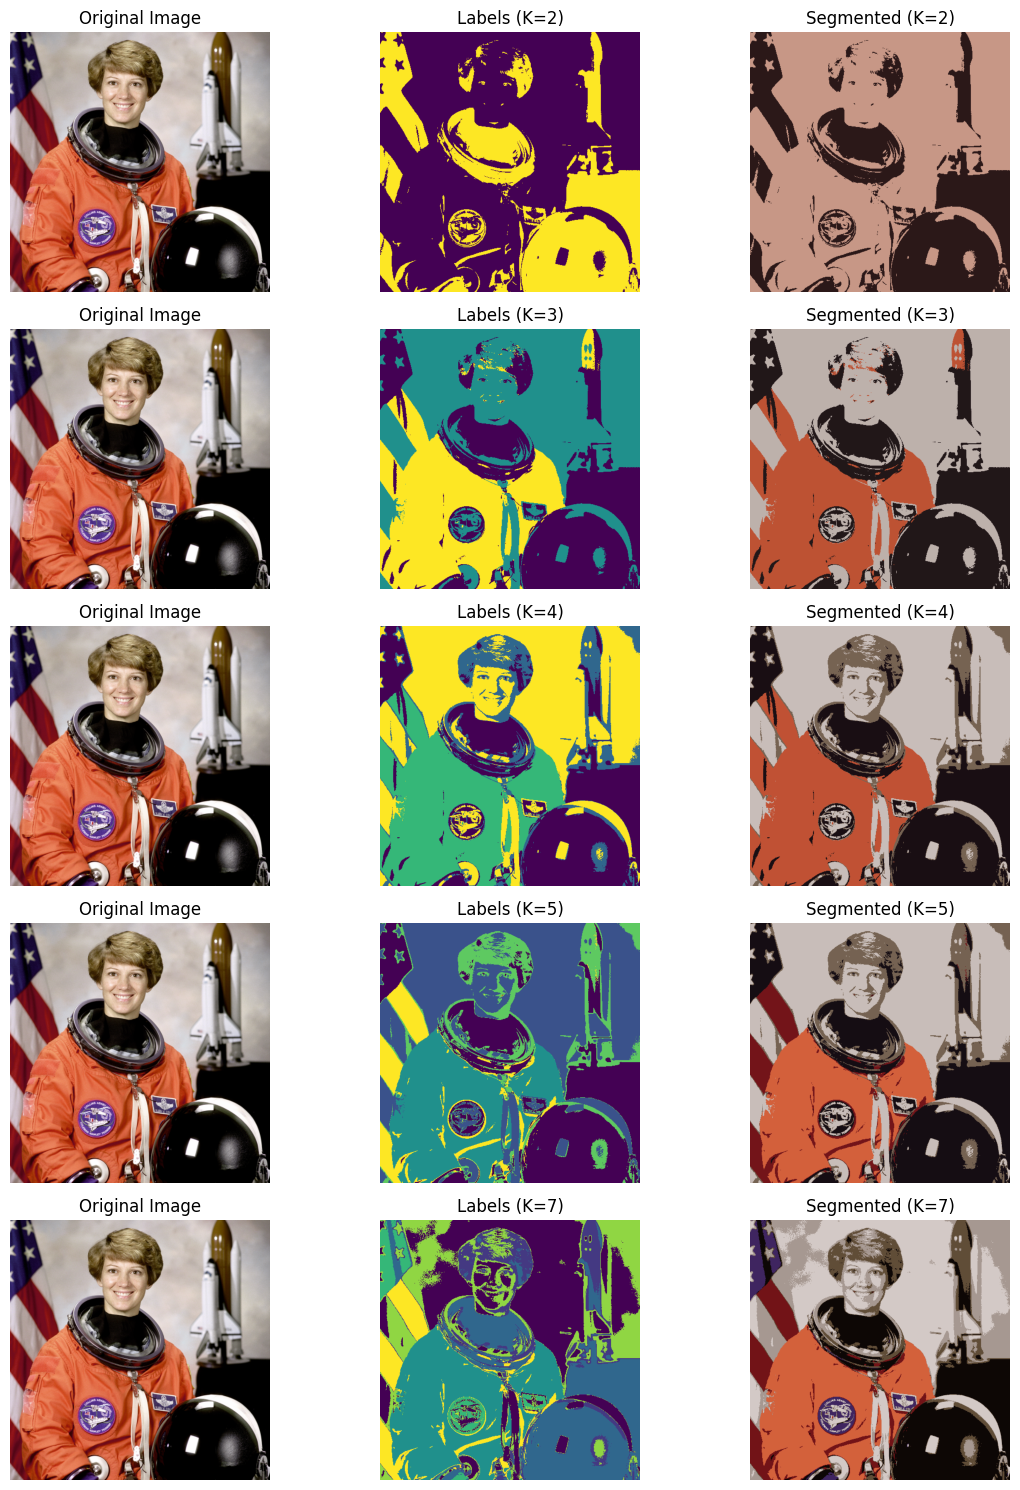

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Load image
image_astro = data.astronaut()
image_astro_float = image_astro.astype(float) / 255.0

# 2. Konversi ke Lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Variasi nilai K (urut)
k_values = [2, 3, 4, 5, 7]

# 4. Setup plot
fig, axes = plt.subplots(len(k_values), 3, figsize=(12, 15))

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pixel_labels = kmeans.fit_predict(pixel_features)

    segmented_labels = pixel_labels.reshape(rows, cols)

    # Buat image hasil
    segmented_image_kmeans = np.zeros_like(image_lab)
    centers_lab = kmeans.cluster_centers_

    for j in range(k):
        mask = (pixel_labels == j).reshape(rows, cols)
        segmented_image_kmeans[mask] = centers_lab[j]

    segmented_rgb = lab2rgb(segmented_image_kmeans)

    # Original
    axes[i, 0].imshow(image_astro)
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')

    # Label
    axes[i, 1].imshow(segmented_labels, cmap='viridis')
    axes[i, 1].set_title(f'Labels (K={k})')
    axes[i, 1].axis('off')

    # Hasil segmentasi
    axes[i, 2].imshow(segmented_rgb)
    axes[i, 2].set_title(f'Segmented (K={k})')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

### Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed

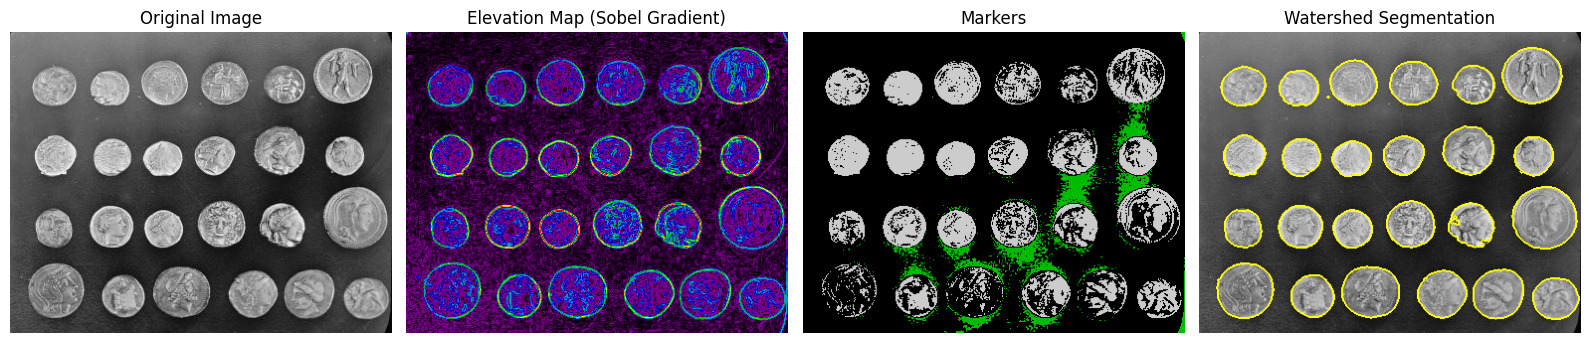

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()

# 2. Hitung gradien citra (sebagai 'topografi')
elevation_map = filters.sobel(image_coins)

# 3. Tentukan marker (penanda awal untuk setiap cekungan/objek)
# Kita bisa menggunakan thresholding untuk mendapatkan marker kasar
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1   # Marker untuk latar belakang
markers[image_coins > 150] = 2  # Marker untuk objek (koin)

# Atau gunakan marker dari local maxima (lebih canggih)
# from skimage.feature import peak_local_max
# image_max = ndi.maximum_filter(image_coins, size=20, mode='constant')
# coordinates = peak_local_max(image_coins, min_distance=20)
# markers = np.zeros(image_coins.shape, dtype=bool)
# markers[tuple(coordinates.T)] = True
# markers = measure.label(markers)

# 4. Terapkan algoritma Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Warnai hasil segmentasi untuk visualisasi
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

### Praktikum 5. Perbandingan Visual Hasil Segmentasi

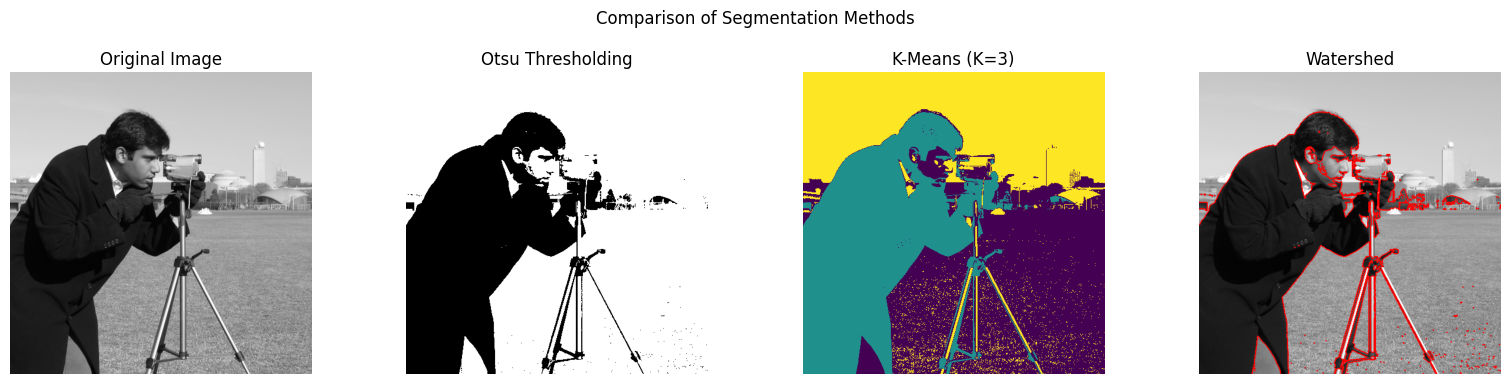

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Pilih satu citra untuk perbandingan (misal: camera)
image = data.camera()
image_float = img_as_float(image)

# 2. Lakukan beberapa metode segmentasi
# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (misal K=3)
# Reshape untuk K-Means (1 fitur: intensitas)
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed (gunakan marker sederhana dari Otsu)
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')  # Gunakan cmap berbeda untuk label
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Gunakan mark_boundaries untuk Watershed agar lebih jelas
segmented_watershed_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1, 0, 0))  # Batas merah
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make space for suptitle
plt.show()

## **Penugasan**

### No 3

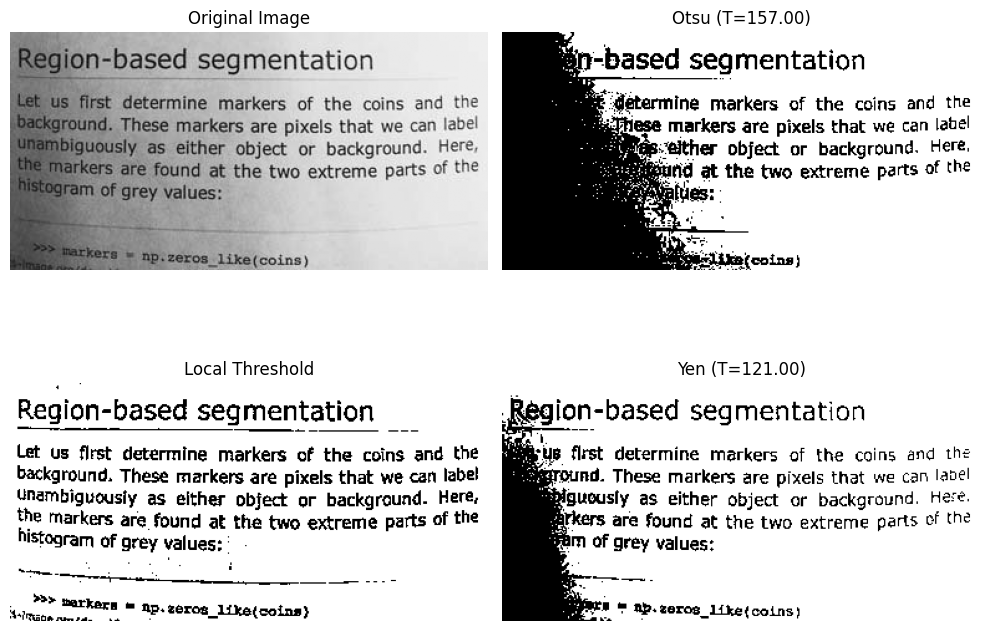

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters

# 1. Load citra page
image = data.page()

# 2. Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# 3. Threshold Local (Adaptive)
block_size = 35
local_thresh = filters.threshold_local(image, block_size, offset=10)
binary_local = image > local_thresh

# 4. Threshold Yen
thresh_yen = filters.threshold_yen(image)
binary_yen = image > thresh_yen

# 5. Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title(f'Otsu (T={thresh_otsu:.2f})')
ax[1].axis('off')

ax[2].imshow(binary_local, cmap='gray')
ax[2].set_title('Local Threshold')
ax[2].axis('off')

ax[3].imshow(binary_yen, cmap='gray')
ax[3].set_title(f'Yen (T={thresh_yen:.2f})')
ax[3].axis('off')

plt.tight_layout()
plt.show()

### No 4

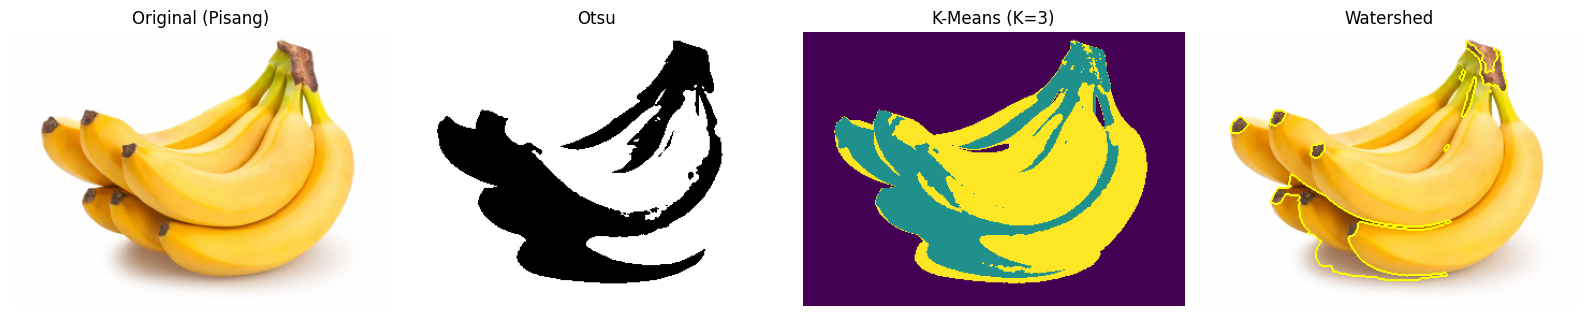

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, segmentation, color
from sklearn.cluster import KMeans
from skimage.transform import resize
from skimage import io
import requests
from io import BytesIO

# =========================
# 1. LOAD GAMBAR (FIX 403)
# =========================
url = "https://cdn.hellodoktor.com/wp-content/uploads/2018/05/shutterstock_575528746-1024x778.jpg"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

# baca image dari bytes
image = io.imread(BytesIO(response.content))

# =========================
# 2. HANDLE RGBA (kalau ada)
# =========================
if image.shape[-1] == 4:
    image = image[:, :, :3]

# resize
image = resize(image, (256, 356), anti_aliasing=True)

# grayscale
image_gray = color.rgb2gray(image)

# =========================
# 3. OTSU
# =========================
thresh = filters.threshold_otsu(image_gray)
binary_otsu = image_gray > thresh

# =========================
# 4. K-MEANS
# =========================
rows, cols, ch = image.shape
pixel_values = image.reshape((-1, 3))

k = 3
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
labels = kmeans.fit_predict(pixel_values)

segmented_kmeans = labels.reshape(rows, cols)

# =========================
# 5. WATERSHED
# =========================
gradient = filters.sobel(image_gray)

markers = np.zeros_like(image_gray, dtype=np.int32)
markers[image_gray < 0.4] = 1
markers[image_gray > 0.7] = 2

ws = segmentation.watershed(gradient.astype(np.float64), markers)
ws_boundaries = segmentation.mark_boundaries(image, ws)

# =========================
# 6. VISUALISASI
# =========================
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].imshow(image)
ax[0].set_title('Original (Pisang)')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans, cmap='viridis')
ax[2].set_title('K-Means (K=3)')
ax[2].axis('off')

ax[3].imshow(ws_boundaries)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.tight_layout()
plt.show()